## SHAP ANALYSIS

we are trying to explain our model

In [19]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import joblib

df=pd.read_csv("/home/student/Projects/Startup-outcome-intelligence/data/processed/startup_data_final.csv")

## Loading the Model

In [20]:
artifacts=joblib.load("../models/lgbm_model.joblib")

lgbm=artifacts["model"]
threshold=artifacts["threshold"]

## Splitting

In [31]:
x=df.drop(columns=["label"])
y=df["label"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

## SHAP work

In [48]:
explainer=shap.TreeExplainer(lgbm)
sv=explainer(x_test)

vals=sv.values
fail_vals=-vals # cse we trained on -ves , and want to see if we get negatives right

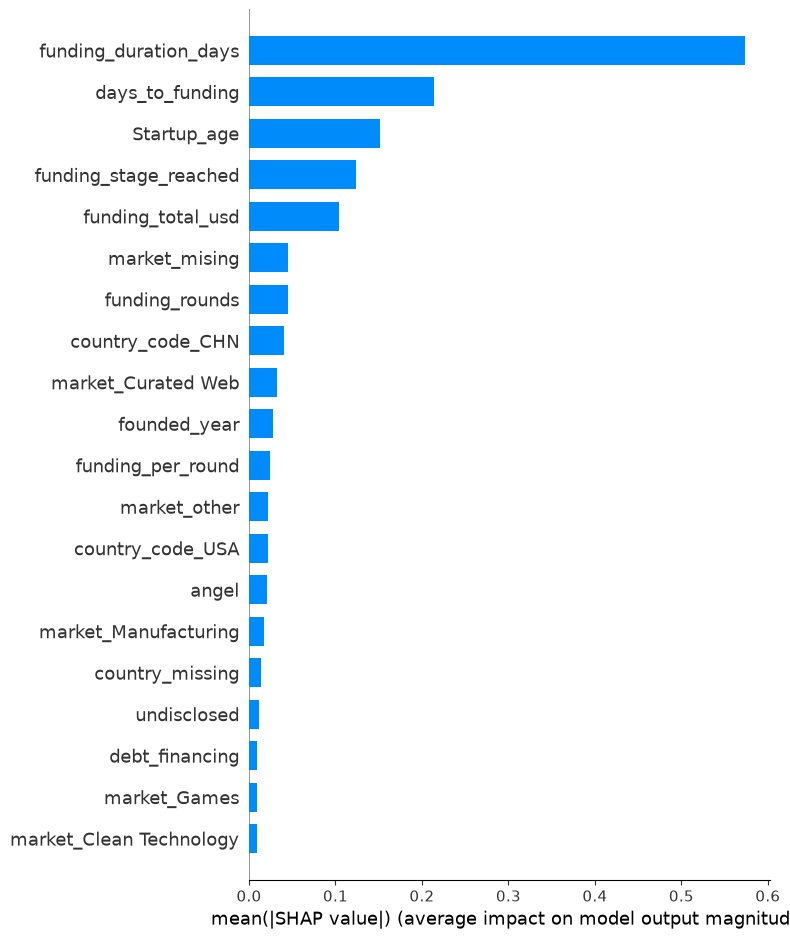

In [49]:
shap.summary_plot(fail_vals,x_test,plot_type="bar") #global feature importance

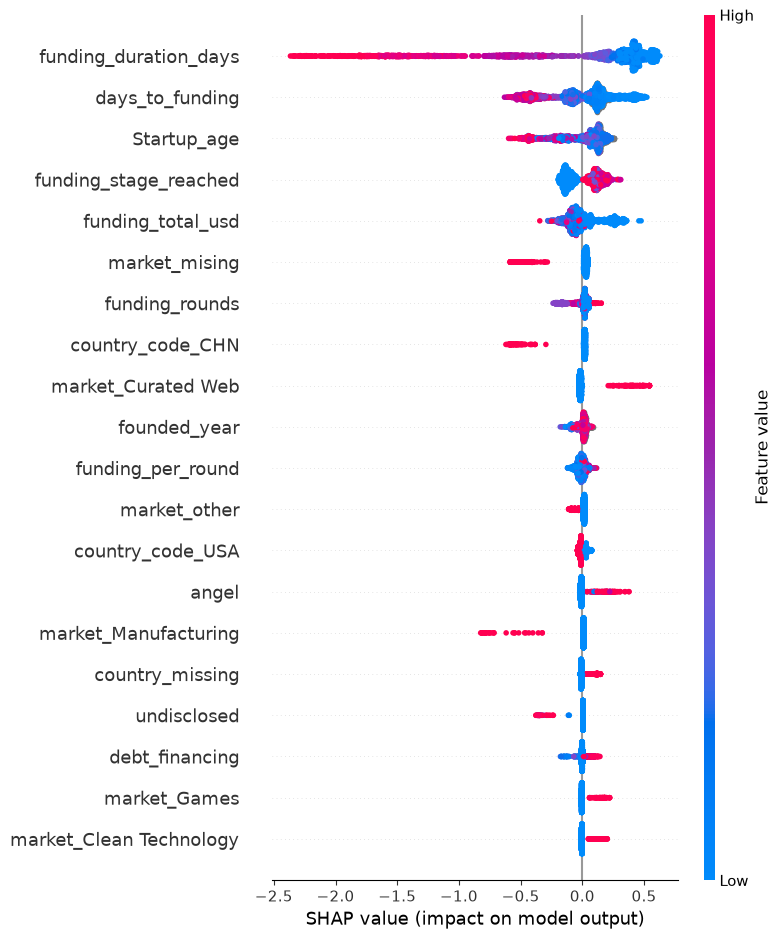

In [50]:
shap.summary_plot(fail_vals, x_test)

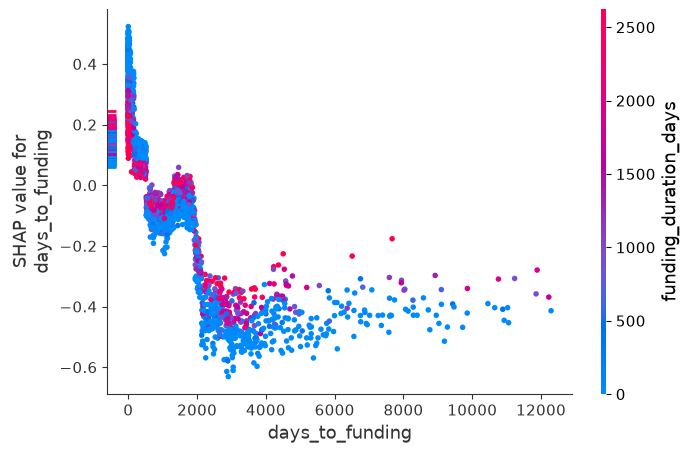

In [51]:
shap.dependence_plot("days_to_funding", fail_vals, x_test)

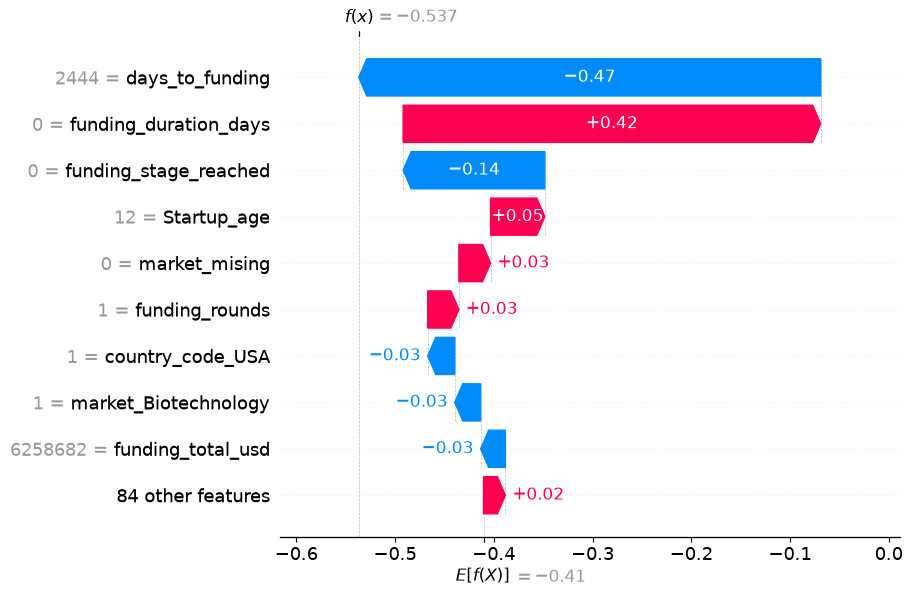

In [55]:
exp_fail = shap.Explanation(
    values=fail_vals,
    base_values=-sv.base_values,
    data=x_test.values,
    feature_names=list(x_test.columns),
)

idx=0
shap.plots.waterfall(exp_fail[idx])